In [1]:
#Load data (with indicators)
import pandas as pd

# Load final dataset (before indicators)
df = pd.read_csv("final_output/psx_final_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Sort properly
df = df.sort_values(["Ticker", "Date"])


In [2]:
#Strategy Function (MA Crossover) 
#this will generate buy sale signlas
def generate_signals(df):
    df = df.copy()
    
    # Strategy: MA20 & MA50
    df["Signal"] = 0
    
    # BUY when MA20 crosses above MA50
    df.loc[(df["MA20"] > df["MA50"]) & (df["MA20"].shift(1) <= df["MA50"].shift(1)), "Signal"] = 1
    
    # SELL when MA20 crosses below MA50
    df.loc[(df["MA20"] < df["MA50"]) & (df["MA20"].shift(1) >= df["MA50"].shift(1)), "Signal"] = -1
    
    return df


In [3]:
#Backtest Function
#simulate profit by “buying” on BUY signal and “selling" on SELL signal.
def backtest(df):
    df = df.copy()
    df["Position"] = 0

    # 1 = holding stock, 0 = not holding
    df.loc[df["Signal"] == 1, "Position"] = 1
    df.loc[df["Signal"] == -1, "Position"] = 0

    # Carry forward position (forward fill)
    df["Position"] = df["Position"].replace(0, None).ffill().fillna(0)

    # Daily Returns
    df["Daily_Return"] = df["Close"].pct_change()
    
    # Strategy Returns
    df["Strategy_Return"] = df["Daily_Return"] * df["Position"]
    
    # Cumulative returns
    df["Cumulative_Return"] = (1 + df["Strategy_Return"]).cumprod()

    df["BuyHold_Return"] = df["Daily_Return"]
    df["BuyHold_Cumulative"] = (1 + df["BuyHold_Return"].fillna(0)).cumprod()

    return df


In [4]:
#Apply Strategy to ALL Companies
import os

out_dir = "final_output/trading_strategy"
os.makedirs(out_dir, exist_ok=True)

tickers = df["Ticker"].unique()

for ticker in tickers:
    df_t = pd.read_csv(f"final_output/technical_indicators/{ticker}_indicators.csv")
    df_t["Date"] = pd.to_datetime(df_t["Date"])
    
    df_t = generate_signals(df_t)
    df_t = backtest(df_t)
    
    save_path = f"{out_dir}/{ticker}_strategy.csv"
    df_t.to_csv(save_path, index=False)

    print(f"✔ Strategy completed for {ticker}")


C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\500356798.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Position"] = df["Position"].replace(0, None).ffill().fillna(0)
C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\500356798.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Position"] = df["Position"].replace(0, None).ffill().fillna(0)
C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\500356798.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a 

✔ Strategy completed for DGKC
✔ Strategy completed for HBL
✔ Strategy completed for LUCK
✔ Strategy completed for MCB
✔ Strategy completed for OGDC


C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\500356798.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Position"] = df["Position"].replace(0, None).ffill().fillna(0)
C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\500356798.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Position"] = df["Position"].replace(0, None).ffill().fillna(0)


In [5]:
#Plot Trading Strategy (Optional)
import matplotlib.pyplot as plt

def plot_strategy(df, ticker):
    plt.figure(figsize=(14,6))
    
    plt.plot(df["Date"], df["Close"], label="Price", alpha=0.5)
    plt.plot(df["Date"], df["MA20"], label="MA20")
    plt.plot(df["Date"], df["MA50"], label="MA50")
    
    # Buy signals
    buys = df[df["Signal"] == 1]
    sells = df[df["Signal"] == -1]
    
    plt.scatter(buys["Date"], buys["Close"], marker="^", color="green", label="Buy", s=100)
    plt.scatter(sells["Date"], sells["Close"], marker="v", color="red", label="Sell", s=100)
    
    plt.title(f"{ticker} — MA Crossover Strategy")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()


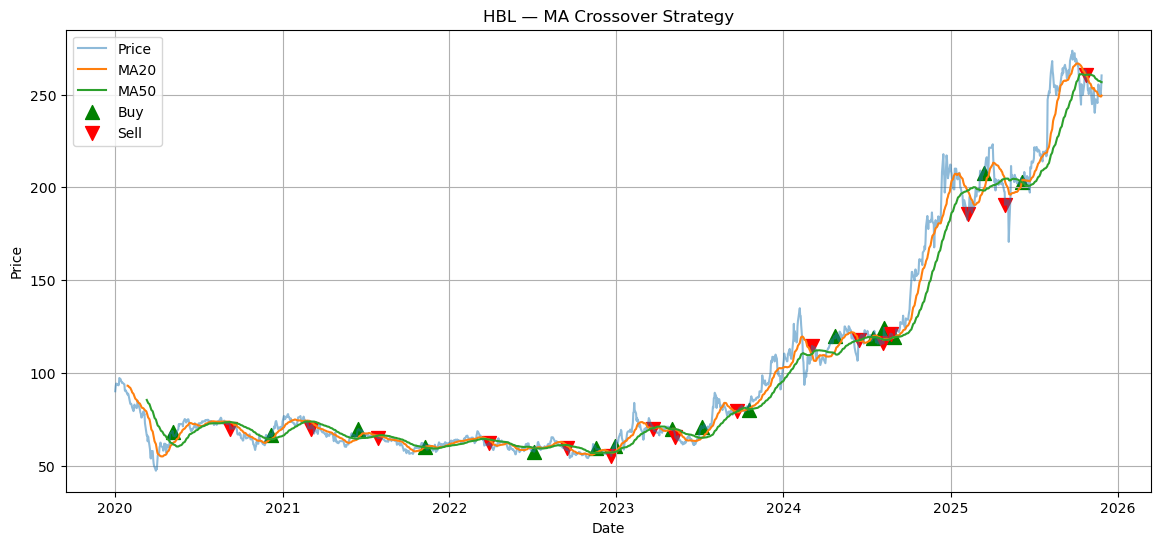

In [6]:
#to run for one stock 
df_t = pd.read_csv("final_output/trading_strategy/OGDC_strategy.csv")
df_t["Date"] = pd.to_datetime(df_t["Date"])
plot_strategy(df_t, "HBL")


## Performance indicators

In [7]:
import pandas as pd

df = pd.read_csv("final_output/psx_final_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])


In [8]:
#Create a Metrics Function
import numpy as np

def calculate_metrics(df):
    df = df.copy()
    
    # Strategy cumulative return
    total_return = df["Cumulative_Return"].iloc[-1] - 1
    
    # Annualized return
    days = (df["Date"].iloc[-1] - df["Date"].iloc[0]).days
    annualized_return = (1 + total_return) ** (365 / days) - 1 if days > 0 else 0
    
    # Daily volatility
    daily_volatility = df["Strategy_Return"].std()
    
    # Annualized volatility
    annualized_volatility = daily_volatility * np.sqrt(252)
    
    # Sharpe Ratio (risk-free = 0)
    sharpe_ratio = (
        annualized_return / annualized_volatility 
        if annualized_volatility != 0 else 0
    )
    
    # Max Drawdown
    df["Peak"] = df["Cumulative_Return"].cummax()
    df["Drawdown"] = (df["Cumulative_Return"] - df["Peak"]) / df["Peak"]
    max_drawdown = df["Drawdown"].min()
    
    # Count trades
    buy_signals = (df["Signal"] == 1).sum()
    sell_signals = (df["Signal"] == -1).sum()
    trades = min(buy_signals, sell_signals)
    # Buy-and-Hold results
    buyhold_total = df["BuyHold_Cumulative"].iloc[-1] - 1
    buyhold_annualized = (1 + buyhold_total) ** (365 / days) - 1 if days > 0 else np.nan
    buyhold_vol = df["Daily_Return"].std() * np.sqrt(252)
    buyhold_sharpe = buyhold_annualized / buyhold_vol if buyhold_vol != 0 else np.nan
    
    # Buy-and-Hold max drawdown
    df["BH_Peak"] = df["BuyHold_Cumulative"].cummax()
    df["BH_Drawdown"] = (df["BuyHold_Cumulative"] - df["BH_Peak"]) / df["BH_Peak"]
    buyhold_maxdd = df["BH_Drawdown"].min()
    # Win Rate
    win_rate = 0
    if trades > 0:
        df_trades = df[df["Signal"] != 0]
        df_trades.loc[:, "Trade_Return"] = df_trades["Close"].pct_change()
        wins = (df_trades["Trade_Return"] > 0).sum()
        win_rate = wins / trades

    return {
        "Total_Return": total_return,
        "Annualized_Return": annualized_return,
        "Annualized_Volatility": annualized_volatility,
        "Sharpe_Ratio": sharpe_ratio,
        "Max_Drawdown": max_drawdown,
        "Number_of_Trades": trades,
        "Win_Rate": win_rate,
        "BH_Total_Return": buyhold_total,
        "BH_Annualized_Return": buyhold_annualized,
        "BH_Sharpe": buyhold_sharpe,
        "BH_Max_Drawdown": buyhold_maxdd

    }


In [9]:
#Loop Through All Companies & Save Metrics
import pandas as pd
import os

metrics_list = []

tickers = df["Ticker"].unique()

for ticker in tickers:
    strategy_path = f"final_output/trading_strategy/{ticker}_strategy.csv"
    df_t = pd.read_csv(strategy_path)
    df_t["Date"] = pd.to_datetime(df_t["Date"])
    
    metrics = calculate_metrics(df_t)
    metrics["Ticker"] = ticker
    
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)

# Save results
output_path = "final_output/trading_strategy/strategy_performance_metrics.csv"
metrics_df.to_csv(output_path, index=False)

print("✔ Performance metrics saved!")
metrics_df


C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\2467731924.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trades.loc[:, "Trade_Return"] = df_trades["Close"].pct_change()
C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\2467731924.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trades.loc[:, "Trade_Return"] = df_trades["Close"].pct_change()
C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\2467731924.py:49: SettingWithCopyWarning: 
A value is trying to be set on a 

✔ Performance metrics saved!


C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\2467731924.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trades.loc[:, "Trade_Return"] = df_trades["Close"].pct_change()
C:\Users\Kashif Hussain\AppData\Local\Temp\ipykernel_4520\2467731924.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trades.loc[:, "Trade_Return"] = df_trades["Close"].pct_change()


,Total_Return,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Number_of_Trades,Win_Rate,BH_Total_Return,BH_Annualized_Return,BH_Sharpe,BH_Max_Drawdown,Ticker
0,1.855966,0.194321,0.391766,0.496012,-0.713049,17,1.000000,2.060836,0.208404,0.517868,-0.713049,DGKC
1,3.809180,0.304421,0.288976,1.053446,-0.505094,15,1.333333,1.984976,0.203283,0.646988,-0.577535,HBL
2,-0.003311,-0.000561,1.698734,-0.000330,-0.817247,15,1.333333,0.052659,0.008722,0.005118,-0.817247,LUCK
3,4.056537,0.315539,0.226367,1.393927,-0.263724,16,1.312500,2.990896,0.263895,1.057445,-0.392181,MCB
4,2.785340,0.252636,0.325010,0.777317,-0.306244,16,1.187500,1.887829,0.196565,0.563828,-0.513522,OGDC


In [10]:
#create comparison equity curve graph 
def plot_equity_comparison(df, ticker):
    plt.figure(figsize=(12,6))
    
    plt.plot(df["Date"], df["Cumulative_Return"], label="Strategy", color="orange")
    plt.plot(df["Date"], df["BuyHold_Cumulative"], label="Buy & Hold", color="blue")

    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.title(f"{ticker} — Strategy vs Buy & Hold")
    plt.legend()
    plt.grid(True)

    plt.savefig(f"final_output/summary/{ticker}_equity_comparison.png")
    plt.close()


FileNotFoundError: [Errno 2] No such file or directory: 'final_output/summary/DGKC_equity_comparison.png'

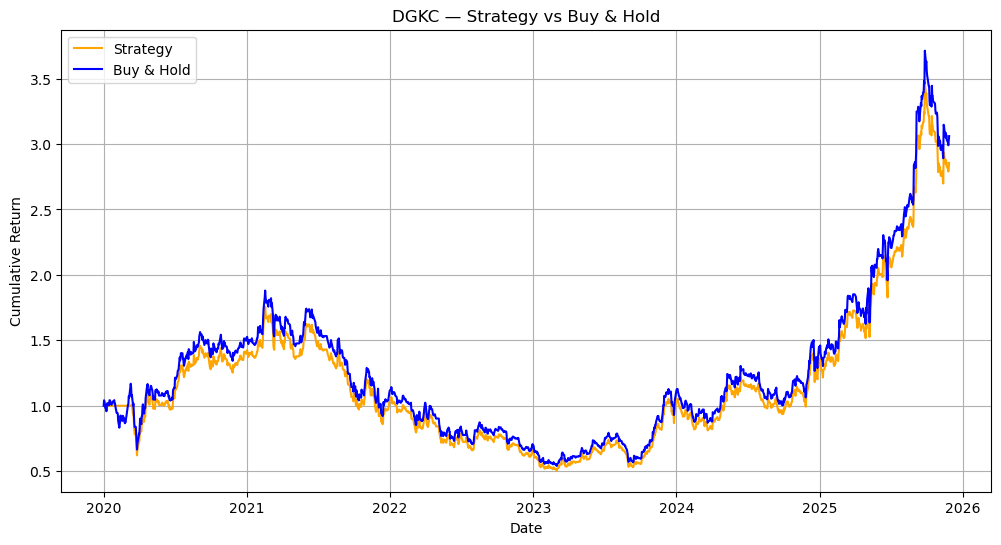

In [11]:
for ticker in tickers:
    df_s = pd.read_csv(f"final_output/trading_strategy/{ticker}_strategy.csv")
    df_s["Date"] = pd.to_datetime(df_s["Date"])
    plot_equity_comparison(df_s, ticker)


## RSI Trading Strategy

In [ ]:
#1) Create folders and import libs (run once)
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# folders
IND_DIR = "final_output/technical_indicators"
MA_STRAT_DIR = "final_output/trading_strategy"           # existing MA strategy files
RSI_STRAT_DIR = "final_output/trading_strategy_rsi"      # new RSI strategy files
SUMMARY_DIR = "final_output/summary"
os.makedirs(RSI_STRAT_DIR, exist_ok=True)
os.makedirs(SUMMARY_DIR, exist_ok=True)


In [ ]:
# 2) Helper: RSI signal generator
'''We use the common rule: buy when RSI crosses above 30 (exits oversold), 
sell when RSI crosses below 70 (enters overbought). 
This prevents immediate flips and avoids acting on single-day noise. '''
def generate_rsi_signals(df, rsi_col="RSI", low=30, high=70):
    """
    df: DataFrame containing 'Date', 'Close', and RSI column
    returns df with a 'RSI_Signal' column: 1 for buy, -1 for sell, 0 otherwise
    """
    df = df.copy()
    df.loc[:, "RSI_Signal"] = 0

    # conditions for cross above/below
    cond_buy = (df[rsi_col] > low) & (df[rsi_col].shift(1) <= low)   # crossed above 30
    cond_sell = (df[rsi_col] < high) & (df[rsi_col].shift(1) >= high) # crossed below 70

    df.loc[cond_buy, "RSI_Signal"] = 1
    df.loc[cond_sell, "RSI_Signal"] = -1

    return df


In [ ]:
#3) Backtest function (same logic as MA backtest)
''' This uses the same position logic: 
when a BUY signal appears,
enter (position=1) and hold until a SELL.
We forward-fill positions. We also compute buy-hold for benchmark. '''

def backtest_strategy(df, signal_col="RSI_Signal"):
    df = df.copy()
    df.loc[:, "Position"] = 0
    df.loc[df[signal_col] == 1, "Position"] = 1
    df.loc[df[signal_col] == -1, "Position"] = 0

    # forward fill: replace 0 -> NaN, forward fill, fillna(0)
    df.loc[:, "Position"] = df["Position"].replace(0, np.nan).ffill().fillna(0)

    # daily returns
    df.loc[:, "Daily_Return"] = df["Close"].pct_change()

    # strategy return: only when position==1
    df.loc[:, "Strategy_Return"] = df["Daily_Return"] * df["Position"]

    # buy-and-hold (benchmark)
    df.loc[:, "BuyHold_Return"] = df["Daily_Return"]
    df.loc[:, "BuyHold_Cumulative"] = (1 + df["BuyHold_Return"].fillna(0)).cumprod()

    # cumulative strategy
    df.loc[:, "Cumulative_Return"] = (1 + df["Strategy_Return"].fillna(0)).cumprod()

    return df



In [ ]:
# 4) Performance metrics function (same as before but robust)
def calculate_metrics(df):
    """Return a dict of performance metrics from a backtested df (with columns Date, Strategy_Return, Cumulative_Return, BuyHold_Cumulative)."""
    df = df.copy()
    df.loc[:, "Date"] = pd.to_datetime(df["Date"])
    if df.shape[0] < 2:
        return None

    total_return = df["Cumulative_Return"].iloc[-1] - 1
    days = (df["Date"].iloc[-1] - df["Date"].iloc[0]).days
    annualized_return = (1 + total_return) ** (365 / days) - 1 if days > 0 else np.nan

    daily_volatility = df["Strategy_Return"].std()
    annualized_volatility = daily_volatility * np.sqrt(252) if not np.isnan(daily_volatility) else np.nan
    sharpe = annualized_return / annualized_volatility if annualized_volatility and not np.isnan(annualized_volatility) else np.nan

    # drawdowns for strategy
    df.loc[:, "Peak"] = df["Cumulative_Return"].cummax()
    df.loc[:, "Drawdown"] = (df["Cumulative_Return"] - df["Peak"]) / df["Peak"]
    max_drawdown = df["Drawdown"].min()

    # buy-hold metrics
    buy_total = df["BuyHold_Cumulative"].iloc[-1] - 1
    buy_annual = (1 + buy_total) ** (365 / days) - 1 if days > 0 else np.nan
    buy_vol = df["BuyHold_Return"].std() * np.sqrt(252) if not np.isnan(df["BuyHold_Return"].std()) else np.nan
    buy_sharpe = buy_annual / buy_vol if buy_vol and not np.isnan(buy_vol) else np.nan

    # trade counts and win rate
    buy_signals = (df["RSI_Signal"] == 1).sum() if "RSI_Signal" in df.columns else (df["Signal"] == 1).sum()
    sell_signals = (df["RSI_Signal"] == -1).sum() if "RSI_Signal" in df.columns else (df["Signal"] == -1).sum()
    trades = int(min(buy_signals, sell_signals))

    win_rate = np.nan
    if trades > 0:
        # take rows where actual signals occurred (alternating buys/sells)
        df_trades = df[df[["RSI_Signal"]].notnull().any(axis=1)] if "RSI_Signal" in df.columns else df[df[["Signal"]].notnull().any(axis=1)]
        # compute trade-level returns by looking at close change between signal events
        # simpler (approx): compute pct_change on the subset and count positive returns
        df_trades = df_trades.copy()
        df_trades.loc[:, "Trade_Return"] = df_trades["Close"].pct_change()
        wins = (df_trades["Trade_Return"] > 0).sum()
        win_rate = wins / trades if trades > 0 else np.nan

    return {
        "Total_Return": total_return,
        "Annualized_Return": annualized_return,
        "Annualized_Volatility": annualized_volatility,
        "Sharpe_Ratio": sharpe,
        "Max_Drawdown": max_drawdown,
        "Number_of_Trades": trades,
        "Win_Rate": win_rate,
        "BuyHold_Total": buy_total,
        "BuyHold_Annual": buy_annual,
        "BuyHold_Sharpe": buy_sharpe
    }


In [ ]:
# 5) Run RSI strategy for ALL tickers and save outputs
indicator_files = sorted(glob.glob(os.path.join(IND_DIR, "*_indicators.csv")))
summary_rows = []

for f in indicator_files:
    try:
        ticker = os.path.basename(f).split("_")[0].upper()
        df_ind = pd.read_csv(f)
        df_ind.loc[:, "Date"] = pd.to_datetime(df_ind["Date"], errors="coerce")
        df_ind = df_ind.sort_values("Date").reset_index(drop=True)

        # require RSI column present
        if "RSI" not in df_ind.columns:
            print(f"Skipping {ticker} — no RSI column.")
            continue

        # generate RSI signals
        df_rsi = generate_rsi_signals(df_ind, rsi_col="RSI", low=30, high=70)

        # backtest
        df_bt = backtest_strategy(df_rsi, signal_col="RSI_Signal")

        # save strategy CSV
        out_file = os.path.join(RSI_STRAT_DIR, f"{ticker}_rsi_strategy.csv")
        df_bt.to_csv(out_file, index=False)

        # calculate metrics
        metrics = calculate_metrics(df_bt)
        if metrics is None:
            print(f"Not enough data for {ticker}")
            continue

        # add identifier
        metrics["Ticker"] = ticker
        metrics["Strategy_Type"] = "RSI"
        summary_rows.append(metrics)

        # save plots: price + signals and equity
        # PRICE + SIGNALS
        plt.figure(figsize=(12,5))
        plt.plot(df_bt["Date"], df_bt["Close"], label="Close", alpha=0.6)
        if "MA20" in df_bt.columns:
            plt.plot(df_bt["Date"], df_bt["MA20"], label="MA20", linewidth=1)
        if "MA50" in df_bt.columns:
            plt.plot(df_bt["Date"], df_bt["MA50"], label="MA50", linewidth=1)
        buys = df_bt[df_bt["RSI_Signal"] == 1]
        sells = df_bt[df_bt["RSI_Signal"] == -1]
        plt.scatter(buys["Date"], buys["Close"], marker="^", color="green", s=80, label="Buy")
        plt.scatter(sells["Date"], sells["Close"], marker="v", color="red", s=80, label="Sell")
        plt.title(f"{ticker} Price & RSI Signals")
        plt.xlabel("Date"); plt.ylabel("Price")
        plt.legend(); plt.grid(True)
        plt.savefig(os.path.join(SUMMARY_DIR, f"{ticker}_rsi_price_signals.png"))
        plt.close()

        # EQUITY CURVE
        plt.figure(figsize=(10,5))
        plt.plot(df_bt["Date"], df_bt["Cumulative_Return"], label="RSI Strategy Equity")
        plt.plot(df_bt["Date"], df_bt["BuyHold_Cumulative"], label="Buy & Hold", alpha=0.8)
        plt.title(f"{ticker} RSI Strategy Equity vs Buy&Hold")
        plt.xlabel("Date"); plt.ylabel("Cumulative Return")
        plt.legend(); plt.grid(True)
        plt.savefig(os.path.join(SUMMARY_DIR, f"{ticker}_rsi_equity.png"))
        plt.close()

        print(f"RSI strategy processed for {ticker}")

    except Exception as e:
        print("Error for", f, e)

# save summary
summary_df_rsi = pd.DataFrame(summary_rows)
summary_df_rsi.to_csv(os.path.join(SUMMARY_DIR, "rsi_strategy_performance_summary.csv"), index=False)
print("Saved RSI performance summary to:", os.path.join(SUMMARY_DIR, "rsi_strategy_performance_summary.csv"))


In [ ]:
# 6) Compare RSI vs MA strategies (summary table)
''''
Now build a comparison table between RSI and MA strategy metrics. 
This cell loads your MA strategy metrics (previously computed summary) and merges.
'''
# load MA metrics if exists (from previous step earlier you created a CSV)
ma_metrics_path = os.path.join("final_output/trading_strategy", "strategy_performance_metrics.csv")
rsi_summary_path = os.path.join(SUMMARY_DIR, "rsi_strategy_performance_summary.csv")

# if MA metrics file is in different location, adjust path
if os.path.exists(ma_metrics_path) and os.path.exists(rsi_summary_path):
    ma_df = pd.read_csv(ma_metrics_path)
    rsi_df = pd.read_csv(rsi_summary_path)

    # unify column names and keep relevant columns
    # rename MA columns to include suffix
    ma_df_short = ma_df.rename(columns={
        "Total_Return": "MA_Total_Return",
        "Annualized_Return": "MA_Annualized_Return",
        "Sharpe_Ratio": "MA_Sharpe",
        "Max_Drawdown": "MA_Max_Drawdown",
        "Number_of_Trades": "MA_Trades",
        "Win_Rate": "MA_Win_Rate"
    })[["Ticker","MA_Total_Return","MA_Annualized_Return","MA_Sharpe","MA_Max_Drawdown","MA_Trades","MA_Win_Rate"]]

    rsi_df_short = rsi_df.rename(columns={
        "Total_Return": "RSI_Total_Return",
        "Annualized_Return": "RSI_Annualized_Return",
        "Sharpe_Ratio": "RSI_Sharpe",
        "Max_Drawdown": "RSI_Max_Drawdown",
        "Number_of_Trades": "RSI_Trades",
        "Win_Rate": "RSI_Win_Rate"
    })[["Ticker","RSI_Total_Return","RSI_Annualized_Return","RSI_Sharpe","RSI_Max_Drawdown","RSI_Trades","RSI_Win_Rate"]]

    comp = pd.merge(ma_df_short, rsi_df_short, on="Ticker", how="outer")
    comp.to_csv(os.path.join(SUMMARY_DIR, "comparison_rsi_vs_ma.csv"), index=False)
    print("Saved comparison file:", os.path.join(SUMMARY_DIR, "comparison_rsi_vs_ma.csv"))
    display(comp)
else:
    print("MA metrics or RSI summary not found. Check paths:", ma_metrics_path, rsi_summary_path)
